## 00. Imports

In [1]:
import numpy as np

In [2]:
import numpy as np
import networkx as nx
import cv2
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from tensorflow.keras.datasets import mnist

## 01. Downalod the dataset

In [3]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## 02. Preprocess images - skletonize

In [4]:
def preprocess_image(image):
    """Convert an image to binary and skeletonize it."""
    _, binary = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY)
    skeleton = skeletonize(binary // 255)
    return skeleton

## 03. Create graph from the image of the digit

The digit: 7


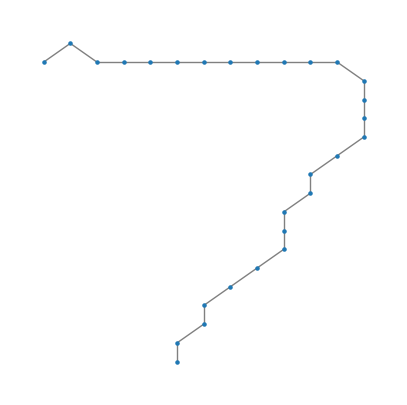

In [5]:
def extract_graph(skeleton):
    """Extract a well-connected graph from a skeletonized image and center it."""
    G = nx.Graph()
    height, width = skeleton.shape

    # Find all active pixel positions
    pixel_positions = np.argwhere(skeleton == 1)

    if len(pixel_positions) == 0:
        return G  # Return empty graph if no skeleton pixels
    
    pos_dict = {}  # Dictionary to store positions

    # Define 8-neighbor connectivity (left, right, up, down, diagonals)
    neighbors = [
        (-1, 0), (1, 0),  # Left, Right
        (0, -1), (0, 1),  # Up, Down
        (-1, -1), (-1, 1), (1, -1), (1, 1)  # Diagonal connections
    ]

    for y, x in pixel_positions:
        # Shift node positions so the centroid aligns at (0,0)
        node = (x, -y)  # Convert to tuple for hashing
        G.add_node(node)
        pos_dict[node] = node  # Store position

        # Connect to valid 8-neighbors
        for dx, dy in neighbors:
            nx_pos, ny_pos = x + dx, y + dy
            neighbor_node = nx_pos, -ny_pos

            if 0 <= nx_pos < width and 0 <= ny_pos < height and skeleton[ny_pos, nx_pos] == 1:
                weight = 1 if abs(dx) + abs(dy) == 1 else np.sqrt(2)  # Euclidean distance for diagonals
                G.add_edge(node, neighbor_node, weight=weight)

    # Assign positions to nodes
    nx.set_node_attributes(G, pos_dict, 'pos')

    return G

def plot_graph(G, ax):
    """Plot the graph on the given axis."""
    pos = {node: node for node in G.nodes()}
    nx.draw(G, pos, ax=ax, node_size=5, edge_color='gray', with_labels=False)

# Test on a sample digit
test_image = x_test[0]  # Select a digit
print("The digit: {}".format(y_test[0]))
skeleton = preprocess_image(test_image)
G = extract_graph(skeleton)
fig, ax = plt.subplots(figsize=(5, 5))
plot_graph(G, ax)

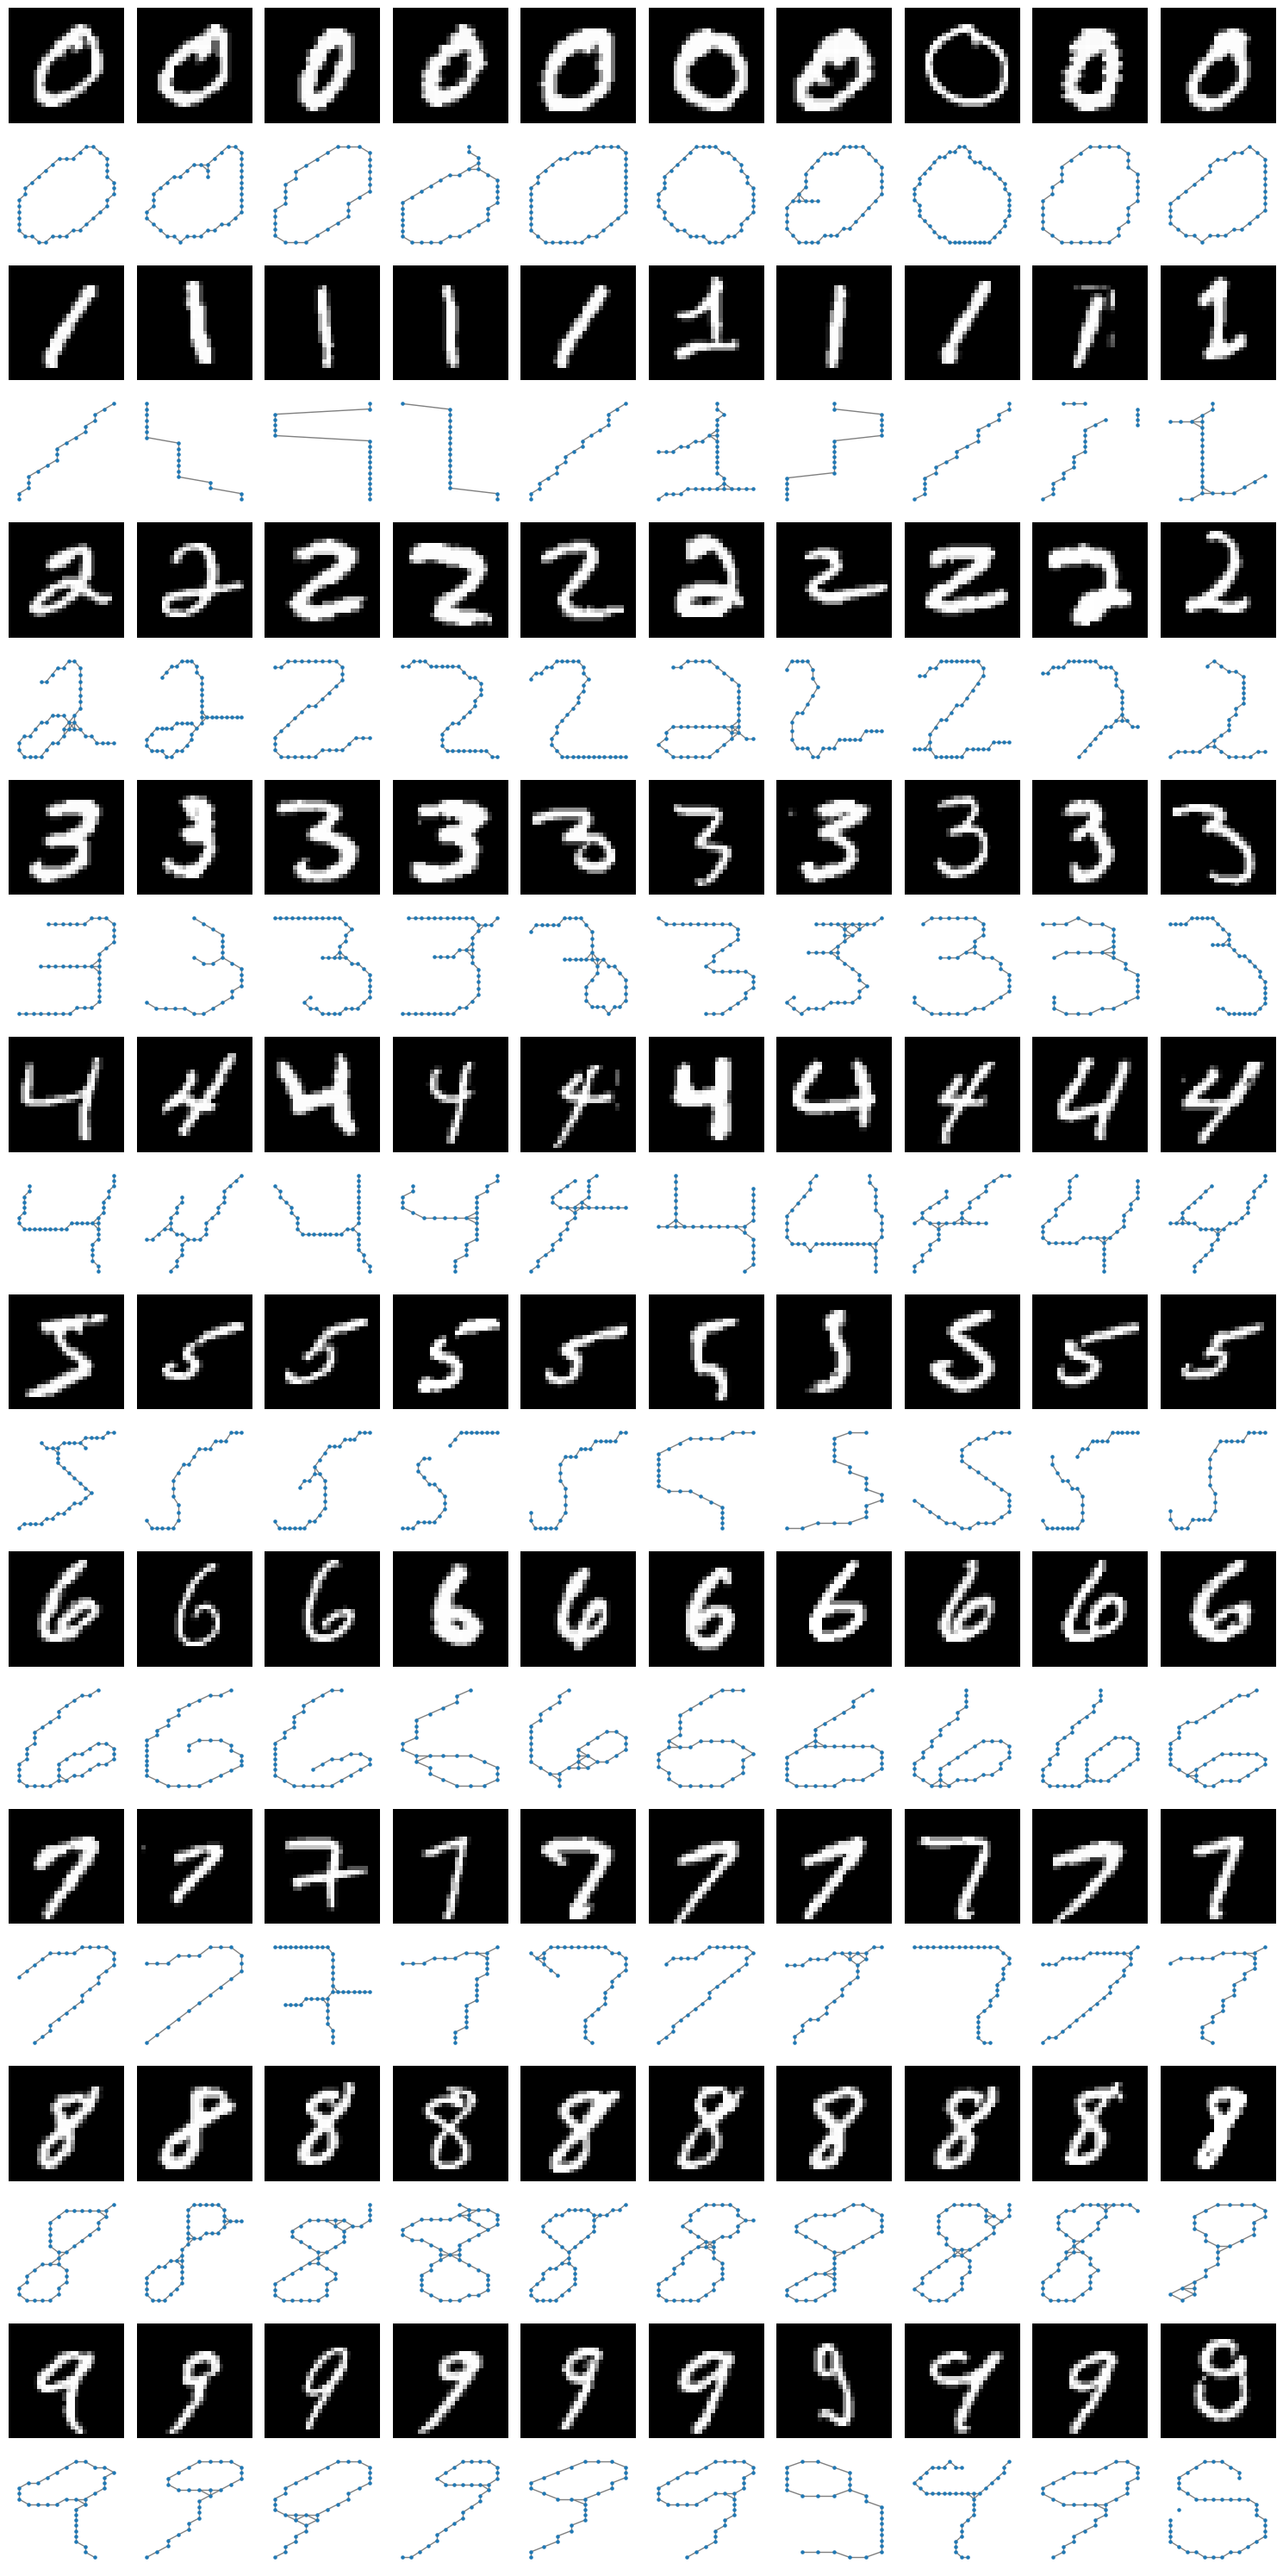

In [6]:
def extract_graph(skeleton):
    """Extract a well-connected graph from a skeletonized image and center it."""
    G = nx.Graph()
    height, width = skeleton.shape

    # Find all active pixel positions
    pixel_positions = np.argwhere(skeleton == 1)

    if len(pixel_positions) == 0:
        return G  # Return empty graph if no skeleton pixels
    
    pos_dict = {}  # Dictionary to store positions

    # Define 8-neighbor connectivity (left, right, up, down, diagonals)
    neighbors = [
        (-1, 0), (1, 0),  # Left, Right
        (0, -1), (0, 1),  # Up, Down
        (-1, -1), (-1, 1), (1, -1), (1, 1)  # Diagonal connections
    ]

    for y, x in pixel_positions:
        # Shift node positions so the centroid aligns at (0,0)
        node = (x, -y)  # Convert to tuple for hashing
        G.add_node(node)
        pos_dict[node] = node  # Store position

        # Connect to valid 8-neighbors
        for dx, dy in neighbors:
            nx_pos, ny_pos = x + dx, y + dy
            neighbor_node = nx_pos, -ny_pos

            if 0 <= nx_pos < width and 0 <= ny_pos < height and skeleton[ny_pos, nx_pos] == 1:
                weight = 1 if abs(dx) + abs(dy) == 1 else np.sqrt(2)  # Euclidean distance for diagonals
                G.add_edge(node, neighbor_node, weight=weight)

    # Assign positions to nodes
    nx.set_node_attributes(G, pos_dict, 'pos')

    return G

# Create a figure with 20 rows (10 digits, each with image + graph) and 10 columns
fig, axes = plt.subplots(20, 10, figsize=(15, 30))

for i in range(10):
    images = x_train[y_train == i][:10]  # Get first 10 images of digit i
    for j, image in enumerate(images):
        axes[2 * i, j].imshow(image, cmap='gray')
        axes[2 * i, j].axis('off')
        
        skeleton = preprocess_image(image)
        G = extract_graph(skeleton)
        
        plot_graph(G, axes[2 * i + 1, j])
        axes[2 * i + 1, j].axis('off')

plt.tight_layout()
plt.show()

## 04. Merge edges with similar directions

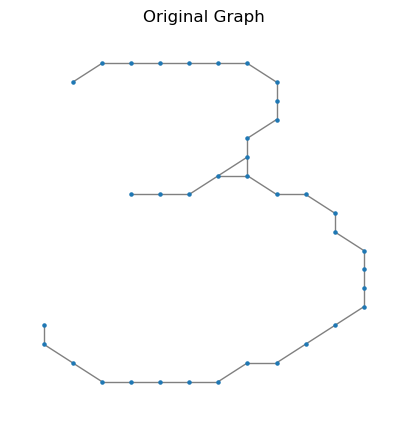

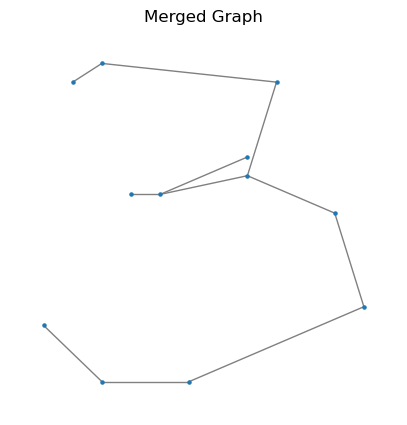

In [7]:
import numpy as np
import networkx as nx

def merge_similar_edges(G, angle_threshold=10):
    """
    Merges edges in the graph that have nearly the same direction.
    Stores the length and original position of each merged edge.
    
    :param G: Input graph with node positions.
    :param angle_threshold: Maximum angle (in degrees) for merging.
    :return: A new graph with merged edges.
    """
    merged_G = nx.Graph()
    pos = nx.get_node_attributes(G, 'pos')  # Get the original positions of the nodes

    # Convert graph edges into vectors (origin, direction)
    edge_vectors = {}
    for u, v in G.edges():
        origin = np.array(pos[u])
        direction = np.array(pos[v]) - np.array(pos[u])
        edge_vectors[(u, v)] = (origin, direction)

    # Function to compute angle between two vectors
    def angle_between(v1, v2):
        cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        return np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))  # Ensure valid range

    visited = set()
    
    for (u, v), (origin, direction) in edge_vectors.items():
        if (u, v) in visited or (v, u) in visited:
            continue
        
        current_path = [(u, v)]  # Store the edges being merged
        total_length = np.linalg.norm(direction)
        merged_origin = origin
        merged_direction = direction
        
        # Try to extend the merged path
        while True:
            next_edge = None
            for neighbor in G.neighbors(v):
                if neighbor == u:  # Avoid going backward
                    continue
                if (v, neighbor) in edge_vectors:
                    _, next_dir = edge_vectors[(v, neighbor)]
                else:
                    continue

                angle = angle_between(merged_direction, next_dir)
                if angle < angle_threshold:
                    next_edge = (v, neighbor)
                    break  # Merge the first valid edge

            if next_edge:
                _, next_dir = edge_vectors[next_edge]
                total_length += np.linalg.norm(next_dir)
                merged_direction += next_dir  # Accumulate the direction
                current_path.append(next_edge)
                visited.add(next_edge)
                u, v = next_edge  # Move forward
            else:
                break  # No more similar edges to merge

        # Add merged edge to new graph
        new_node = tuple(merged_origin)  # Store as tuple for Graph
        new_endpoint = tuple(merged_origin + merged_direction)  # End of merged edge
        merged_G.add_edge(new_node, new_endpoint, length=total_length, original_edges=current_path)

        # Set positions for new nodes
        merged_G.nodes[new_node]['pos'] = merged_origin  # Position of merged node
        merged_G.nodes[new_endpoint]['pos'] = merged_origin + merged_direction  # Position of endpoint of the merged edge

    # Transfer the original positions of existing nodes from the original graph
    for node in G.nodes():
        if node in merged_G.nodes:
            merged_G.nodes[node]['pos'] = pos[node]
    
    return merged_G

# Example usage (assuming skeleton image processing and graph creation as before)
image = x_train[y_train == 3][7]  # Get the first image of digit '3'
skeleton = preprocess_image(image)
G = extract_graph(skeleton)

# Plot the original graph
fig, ax = plt.subplots(figsize=(5, 5))
plot_graph(G, ax)
plt.title("Original Graph")
plt.show()

# Merge edges with an angle threshold
G1 = merge_similar_edges(G, angle_threshold=50)

# Plot the merged graph
fig, ax = plt.subplots(figsize=(5, 5))
plot_graph(G1, ax)
plt.title("Merged Graph")
plt.show()

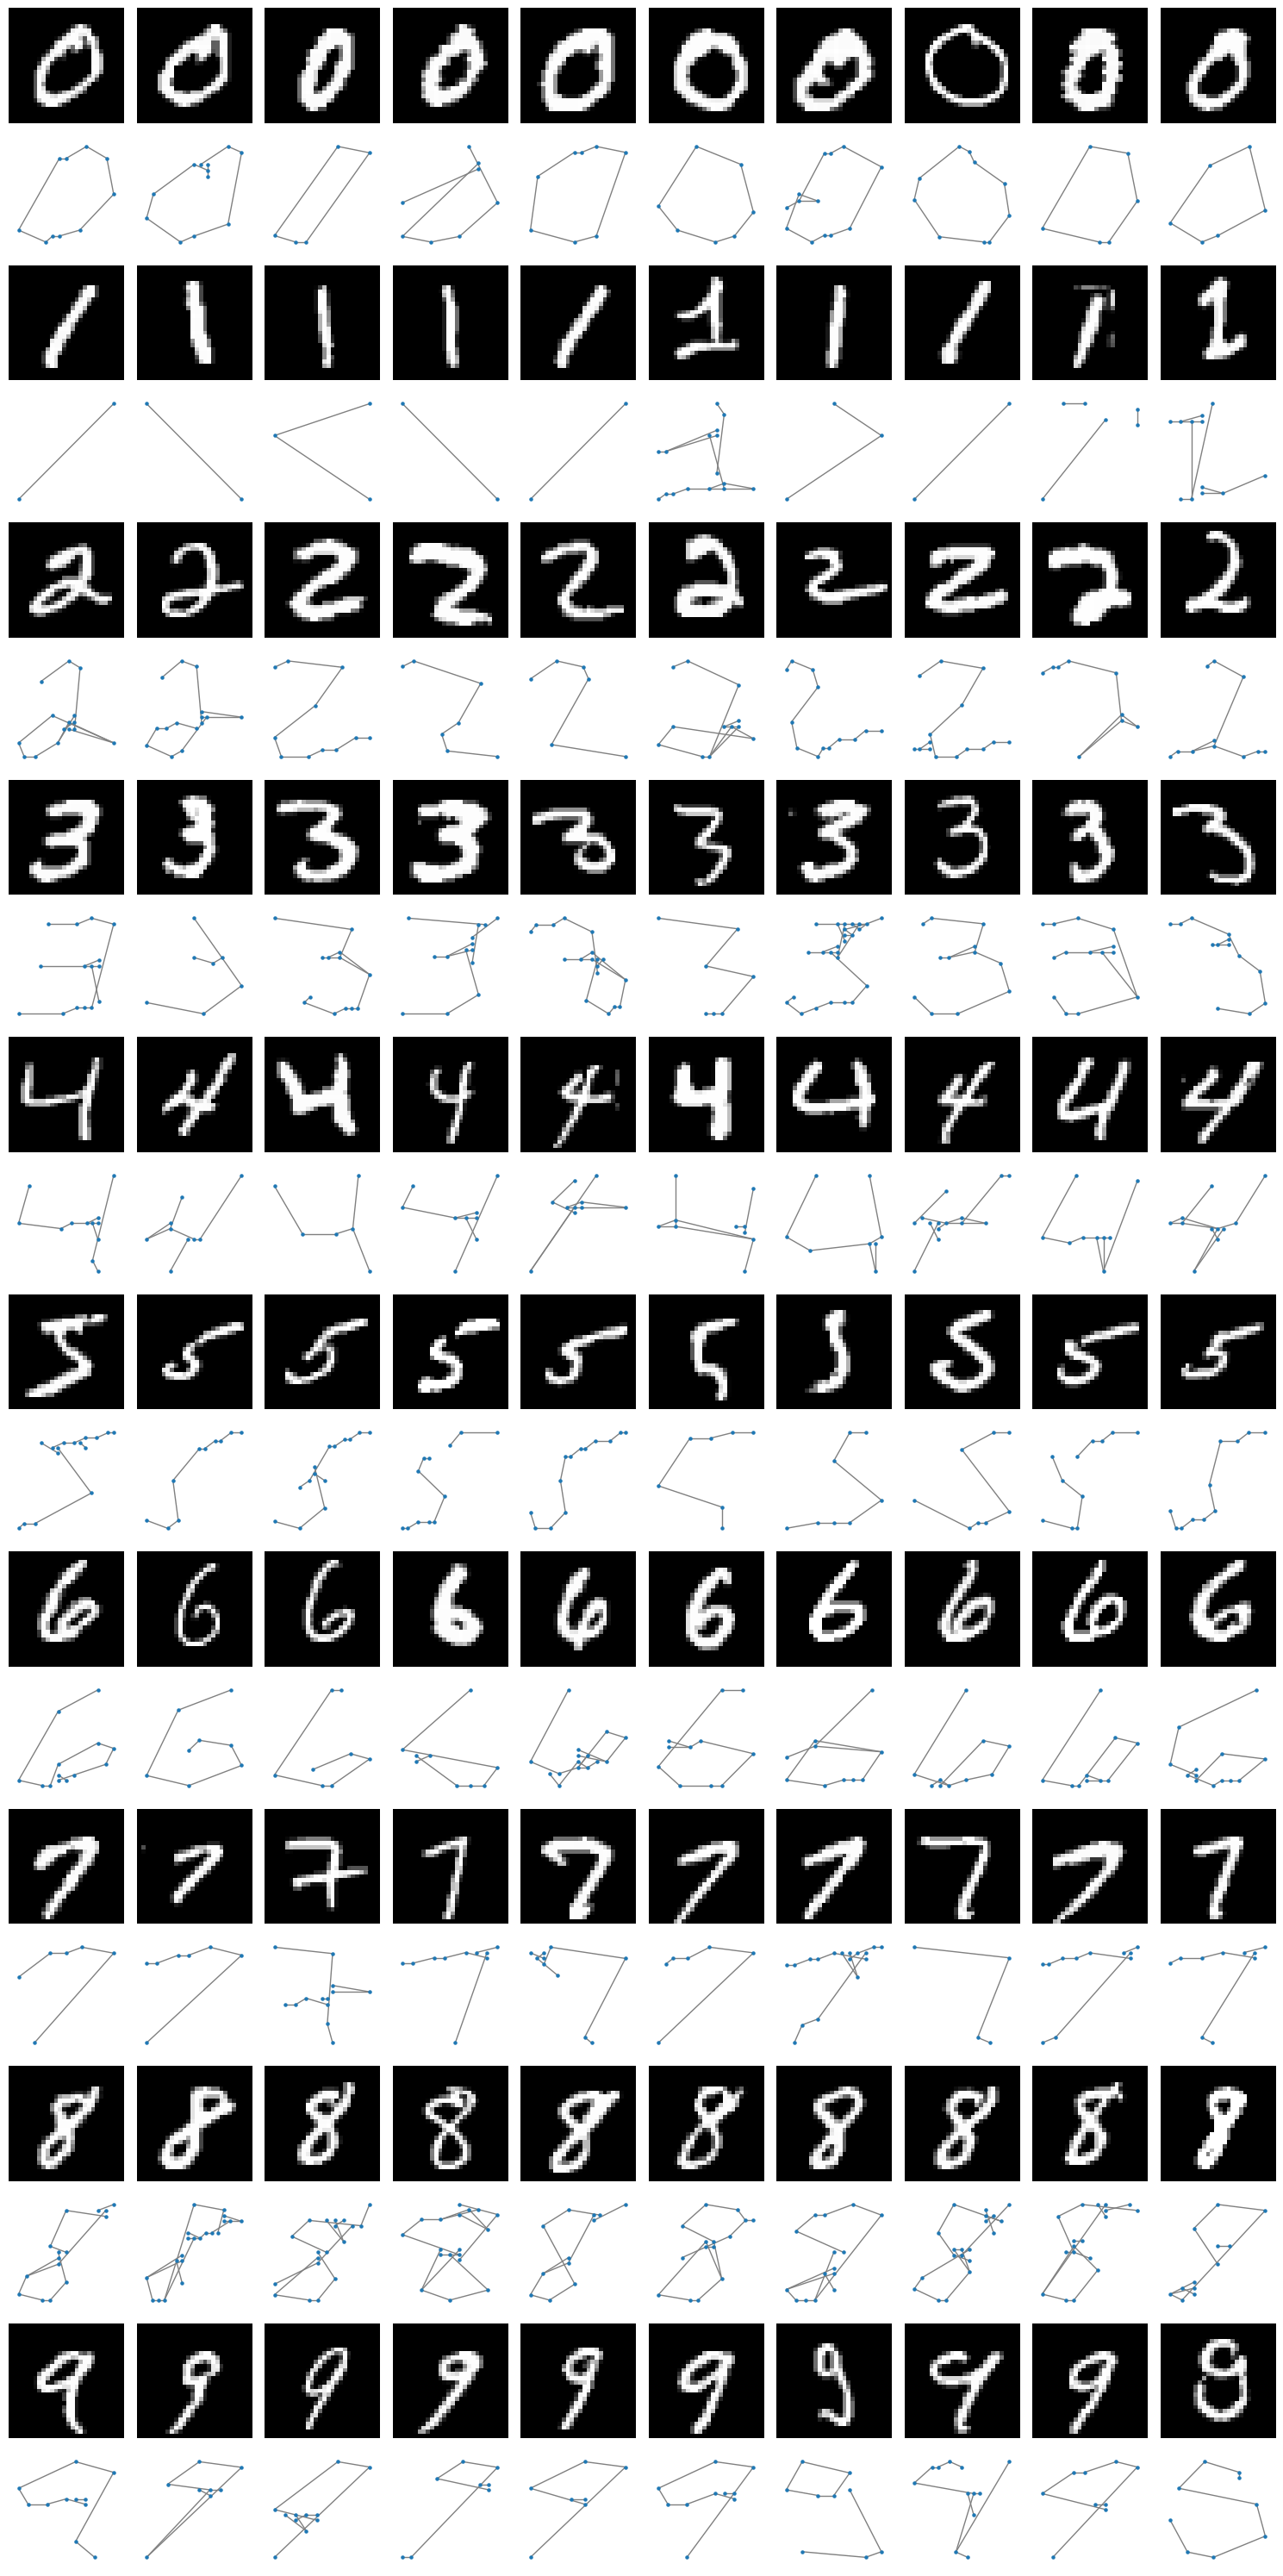

In [237]:
fig, axes = plt.subplots(20, 10, figsize=(15, 30))

for i in range(10):
    images = x_train[y_train == i][:10]  # Get first 10 images of digit i
    for j, image in enumerate(images):
        axes[2 * i, j].imshow(image, cmap='gray')
        axes[2 * i, j].axis('off')
        
        skeleton = preprocess_image(image)
        G = merge_similar_edges(extract_graph(skeleton), angle_threshold=50)
        
        plot_graph(G, axes[2 * i + 1, j])
        axes[2 * i + 1, j].axis('off')

plt.tight_layout()
plt.show()

## 05. Detect curvatures in the graph

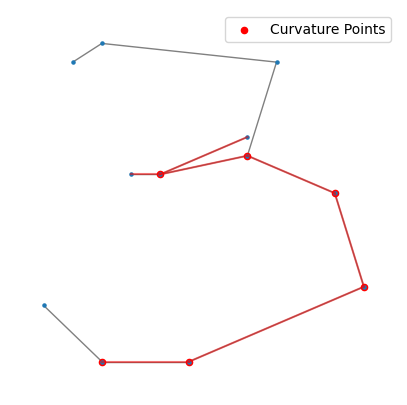

Curvature points: 6 out of 11 edges


In [8]:
def detect_curvatures(merged_G, curvature_threshold=5, min_length=1):
    """
    Detects curvature points in the merged graph based on angle changes.
    
    :param merged_G: Graph with merged edges (from previous step).
    :param curvature_threshold: Angle (degrees) above which we classify as curvature.
    :param min_length: Minimum length of a segment to consider for curvature detection.
    :return: List of curvature points.
    """
    curvature_points = []
    
    # Extract edges and their directions
    edges = list(merged_G.edges(data=True))
    
    def compute_angle(v1, v2):
        """Computes the angle (in degrees) between two vectors."""
        cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        return np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))  # Clip to valid range

    for i in range(len(edges) - 1):
        (u1, v1, data1) = edges[i]
        (u2, v2, data2) = edges[i + 1]

        # Compute direction vectors
        direction1 = np.array(v1) - np.array(u1)
        direction2 = np.array(v2) - np.array(u2)

        # Compute angle change
        angle_change = compute_angle(direction1, direction2)

        # If the angle change is significant, mark it as a curvature
        if angle_change > curvature_threshold and data1["length"] > min_length and data2["length"] > min_length:
            curvature_points.append(v1)  # Store the node where curvature happens

    return curvature_points


# Test curvature detection on the '3' digit
curvature_points = detect_curvatures(G1, curvature_threshold=20, min_length=2)
fig, ax = plt.subplots(figsize=(5, 5))
plot_graph(G1, ax)
curvature_points = np.array(curvature_points)
if len(curvature_points) > 0:
    ax.scatter(curvature_points[:, 0], curvature_points[:, 1], color='red', s=20, label='Curvature Points')
    # color edges as well - only those which connected to curvature points
    for u, v in G1.edges():
        if tuple(v) in curvature_points and tuple(u) in curvature_points:
            ax.plot([u[0], v[0]], [u[1], v[1]], color='red', alpha=0.5)
ax.legend()
plt.show()

print(f"Curvature points: {len(curvature_points)} out of {len(G1.edges())} edges")

## 05.1 New approach to looking for angles

In [ ]:
###### TOOOOOOO slow - way to slow. Didnt work on Windows and does not work on Mac either

def compute_angle_clockwise(v1, v2):
    """Compute the clockwise angle between two vectors."""
    # Using atan2 to calculate angle between vectors
    angle = np.arctan2(v2[1], v2[0]) - np.arctan2(v1[1], v1[0])
    if angle < 0:
        angle += 2 * np.pi  # Ensure angle is positive (clockwise)
    return np.degrees(angle)  # Convert to degrees

def detect_curvatures(G, curvature_threshold=45, min_angle_change=5):
    """
    Detects curvature regions by tracking angle changes between consecutive edges.
    
    :param G: Graph.
    :param pos: Node positions dictionary.
    :param curvature_threshold: Threshold for total curvature (in degrees).
    :param min_angle_change: Minimum angle change to continue the curvature.
    :return: List of curvature regions.
    """
    pos = nx.get_node_attributes(G, 'pos')
    curvature_regions = []  # List to hold the detected curvature regions
    nodes = list(G.nodes)
    
    # Start with the top-left node (the one with smallest x and y coordinates)
    start_node = min(nodes, key=lambda node: (pos[node][0], pos[node][1]))
    print(f"Starting from node: {start_node}")

    current_curvature = []
    total_angle_change = 0
    visited = set()
    node = start_node
    visited.add(node)

    while node:
        neighbors = list(G.neighbors(node))
        if not neighbors:
            break
        
        for neighbor in neighbors:
            if neighbor not in visited:
                # Get the direction vectors for the current edge and the next edge
                current_direction = np.array(neighbor) - np.array(node)
                
                # Find the next neighbor
                next_neighbors = list(G.neighbors(neighbor))
                if not next_neighbors:
                    break
                
                for next_neighbor in next_neighbors:
                    if next_neighbor not in visited:
                        next_direction = np.array(next_neighbor) - np.array(neighbor)
                        
                        # Compute the clockwise angle change between consecutive edges
                        angle_change = compute_angle_clockwise(current_direction, next_direction)
                        
                        # Add to the total curvature
                        total_angle_change += angle_change
                        current_curvature.append((node, neighbor))
                        
                        # If the angle change is negative, end the curvature region
                        if angle_change < min_angle_change:
                            if total_angle_change > curvature_threshold:
                                curvature_regions.append(current_curvature)
                            current_curvature = []
                            total_angle_change = 0
                            visited.add(neighbor)
                            node = neighbor  # Start new curvature from the neighbor
                            break
                        
                        current_direction = next_direction
                        visited.add(neighbor)
                        node = next_neighbor  # Move to the next node
                        
    return curvature_regions

def plot_curvature_regions(G, curvature_regions):
    """Plots the graph with curvature regions."""
    fig, ax = plt.subplots(figsize=(5, 5))
    nx.draw(G, with_labels=True, node_size=100, font_size=8, ax=ax)
    
    # Plot curvature regions
    cmap = plt.cm.get_cmap('rainbow', len(curvature_regions))  # Color map for regions
    for idx, region in enumerate(curvature_regions):
        color = cmap(idx / len(curvature_regions))  # Color for this curvature region
        for u, v in region:
            ax.plot([[u][0], [v][0]], [[u][1], [v][1]], color=color, linewidth=2, alpha=0.8)
    
    plt.title("Curvature Detection")
    plt.show()

# Detect curvature regions
curvature_regions = detect_curvatures(G1, curvature_threshold=45, min_angle_change=5)

# Plot the curvature regions
plot_curvature_regions(G, curvature_regions)

# Output the curvature regions
print(f"Detected {len(curvature_regions)} curvature regions.")
for i, region in enumerate(curvature_regions):
    print(f"Curvature Region {i}: {len(region)} edges")


Starting from node: (8, -19)


KeyboardInterrupt: 

Starting from node: (np.int64(8), np.int64(-19))


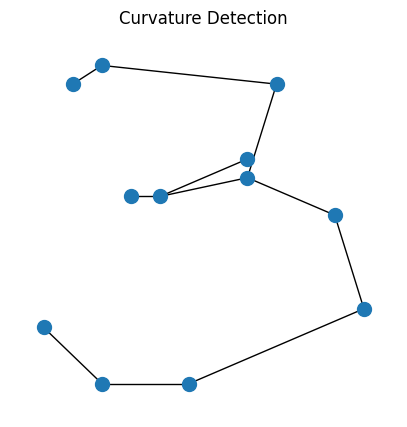

Detected 0 curvature regions.


In [244]:
##### attempt at seeding it  up 

def compute_angle_clockwise(v1, v2):
    """Compute the clockwise angle between two vectors."""
    # Using atan2 to calculate angle between vectors
    angle = np.arctan2(v2[1], v2[0]) - np.arctan2(v1[1], v1[0])
    if angle < 0:
        angle += 2 * np.pi  # Ensure angle is positive (clockwise)
    return np.degrees(angle)  # Convert to degrees


def detect_curvatures(G, curvature_threshold=45, min_angle_change=5):
    """
    Detects curvature regions by tracking angle changes between consecutive edges.
    
    :param G: Graph.
    :param curvature_threshold: Threshold for total curvature (in degrees).
    :param min_angle_change: Minimum angle change to continue the curvature.
    :return: List of curvature regions.
    """
    pos = {node: np.array(coord) for node, coord in nx.get_node_attributes(G, 'pos').items()}  # Store as NumPy arrays
    if not pos:
        raise ValueError("Position dictionary is empty. Ensure the graph has node attributes 'pos'.")

    curvature_regions = []  # List to hold detected curvature regions
    nodes = list(G.nodes)
    
    # Find the starting node (smallest x, then y)
    start_node = min(nodes, key=lambda node: tuple(pos[node]))
    print(f"Starting from node: {start_node}")

    visited = set()
    queue = [(start_node, None, None, 0)]  # (current_node, previous_node, previous_direction, total_angle_change)

    while queue:
        node, prev_node, prev_direction, total_angle_change = queue.pop()
        if node in visited:
            continue
        visited.add(node)

        neighbors = list(G.neighbors(node))
        if not neighbors:
            continue

        for neighbor in neighbors:
            if neighbor == prev_node or neighbor in visited:
                continue

            # Compute the direction vector
            current_direction = pos[neighbor] - pos[node]
            if prev_direction is not None:
                angle_change = compute_angle_clockwise(prev_direction, current_direction)
                total_angle_change += angle_change

                # If the angle change is below the threshold, stop tracking
                if angle_change < min_angle_change:
                    if total_angle_change > curvature_threshold:
                        curvature_regions.append([(prev_node, node)])  # Store the last segment
                    total_angle_change = 0  # Reset curvature tracking

            queue.append((neighbor, node, current_direction, total_angle_change))  # Continue traversal

    return curvature_regions

def plot_curvature_regions(G, curvature_regions):
    """Plots the graph with curvature regions."""
    pos = nx.get_node_attributes(G, 'pos')
    fig, ax = plt.subplots(figsize=(5, 5))
    nx.draw(G, pos, with_labels=False, node_size=100, font_size=8, ax=ax)
    
    cmap = plt.cm.rainbow
    for idx, region in enumerate(curvature_regions):
        color = cmap(idx / len(curvature_regions))  # Assign colors
        for u, v in region:
            ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color=color, linewidth=2, alpha=0.8)

    plt.title("Curvature Detection")
    plt.show()

# Example usage:
curvature_regions = detect_curvatures(G1, curvature_threshold=1, min_angle_change=5)

# Plot the curvature regions
plot_curvature_regions(G1, curvature_regions)

# Output the curvature regions
print(f"Detected {len(curvature_regions)} curvature regions.")
for i, region in enumerate(curvature_regions):
    print(f"Curvature Region {i}: {len(region)} edges")


C:\Users\ewa.miazga\AppData\Local\Temp\ipykernel_26240\1180110621.py:112: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('rainbow', len(curvature_regions))  # Color map


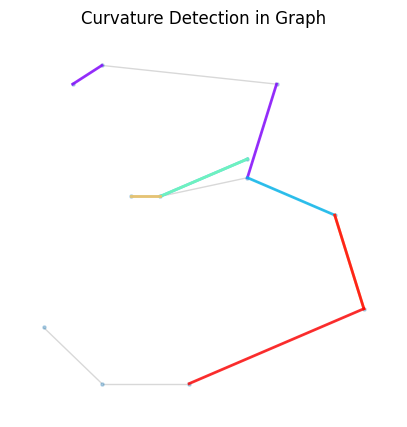

Detected 5 curvature regions.
Region 0: 2 edges
Region 1: 2 edges
Region 2: 2 edges
Region 3: 2 edges
Region 4: 2 edges


In [ ]:
def detect_global_curvatures(merged_G, curvature_threshold=45, window_size=4, min_length=1, max_angle_change=90):
    """
    Detects curvature regions based on changes in direction over multiple edges.
    
    :param merged_G: Graph with merged edges.
    :param curvature_threshold: Total angle (degrees) over the window to classify as curvature.
    :param window_size: Number of consecutive edges to consider.
    :param min_length: Minimum length of an edge to be considered.
    :param max_angle_change: Maximum allowed angle change between consecutive edges to keep curvature continuous.
    :return: List of curvature regions (each region is a list of edges).
    """
    curvature_regions = []
    edges = list(merged_G.edges(data=True))

    def compute_angle(v1, v2):
        """Computes the angle (in degrees) between two vectors."""
        cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        return np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))  # Clip to valid range

    def is_direction_change_large(direction1, direction2, max_angle_change):
        """Checks if the angle change between two directions exceeds the allowed threshold."""
        angle_change = compute_angle(direction1, direction2)
        return angle_change > max_angle_change

    i = 0
    while i < len(edges) - (window_size - 1):
        total_angle_change = 0
        curvature_edges = []

        # Compute total angle change over the window of edges
        for j in range(window_size - 1):
            (u1, v1, data1) = edges[i + j]
            (u2, v2, data2) = edges[i + j + 1]

            # Compute direction vectors
            direction1 = np.array(v1) - np.array(u1)
            direction2 = np.array(v2) - np.array(u2)

            # Check if the direction change is too large
            if is_direction_change_large(direction1, direction2, max_angle_change):
                # If the angle change is too large, terminate the current curvature region
                if total_angle_change > curvature_threshold:
                    curvature_regions.append(curvature_edges)
                # Start a new region after the large angle change
                curvature_edges = [(u1, v1)]
                total_angle_change = 0
                break
            else:
                # Compute angle change and accumulate it
                angle_change = compute_angle(direction1, direction2)
                total_angle_change += angle_change

                # Store edges for grouping
                curvature_edges.append((u1, v1))

        # If the total angle change exceeds the curvature threshold, mark as a curvature region
        if total_angle_change > curvature_threshold:
            curvature_regions.append(curvature_edges)

        # Move the window forward
        i += 1

    # After finding regions, ensure they are connected via nodes
    final_curvature_regions = []
    for region in curvature_regions:
        connected_edges = []
        nodes_in_region = set()
        
        for u, v in region:
            connected_edges.append((u, v))
            nodes_in_region.add(u)
            nodes_in_region.add(v)
        
        # Check connectivity between the edges
        if len(nodes_in_region) > 1:
            final_curvature_regions.append(connected_edges)

    return final_curvature_regions


def plot_graph(G, ax=None):
    """
    Plots the graph with the edges and nodes. Helper function for visualizing the graph.
    
    :param G: NetworkX graph.
    :param ax: Matplotlib axis for plotting.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    pos = {node: node for node in G.nodes()}  # Simplified positions for plotting
    nx.draw(G, pos, ax=ax, node_size=5, edge_color='gray', alpha=0.5)


def plot_curvature_regions(G, curvature_regions):
    """
    Plots the graph with different colors for each detected curvature region.
    
    :param G: Graph.
    :param curvature_regions: List of curvature regions (each region is a list of edges).
    """
    fig, ax = plt.subplots(figsize=(5, 5))
    
    # Draw the entire graph in light gray
    pos = {node: node for node in G.nodes()}  # Node positions
    nx.draw(G, pos, node_size=5, edge_color='gray', alpha=0.3, ax=ax)

    # Plot each curvature region in a different color
    cmap = plt.cm.get_cmap('rainbow', len(curvature_regions))  # Color map

    for idx, region in enumerate(curvature_regions):
        color = cmap(idx / len(curvature_regions))  # Assign color
        for u, v in region:
            ax.plot([u[0], v[0]], [u[1], v[1]], color=color, linewidth=2, alpha=0.8)

    plt.title("Curvature Detection in Graph")
    plt.show()


# Example usage (you would need to provide your graph `G1`):
curvature_regions = detect_global_curvatures(G1, curvature_threshold=80, window_size=3, min_length=2, max_angle_change=120)
plot_curvature_regions(G1, curvature_regions)
print(f"Detected {len(curvature_regions)} curvature regions.")

# Print how many edges are in each curvature region
for i, region in enumerate(curvature_regions):
    print(f"Region {i}: {len(region)} edges")

C:\Users\ewa.miazga\AppData\Local\Temp\ipykernel_26240\745460059.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('rainbow', len(curvature_regions))  # Color map


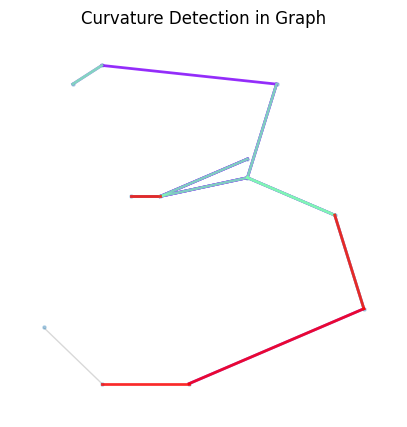

Detected 3 curvature regions.


In [ ]:
def detect_global_curvatures(merged_G, curvature_threshold=30, window_size=4, min_length=1):
    """
    Detects curvature regions based on changes in direction over multiple edges.
    
    :param merged_G: Graph with merged edges.
    :param curvature_threshold: Total angle (degrees) over the window to classify as curvature.
    :param window_size: Number of consecutive edges to consider.
    :param min_length: Minimum length of an edge to be considered.
    :return: List of curvature regions (each region is a list of edges).
    """
    curvature_regions = []
    edges = list(merged_G.edges(data=True))

    def compute_angle(v1, v2):
        """Computes the angle (in degrees) between two vectors."""
        cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        return np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))  # Clip to valid range

    def check_edge_connection(edge1, edge2, connection_threshold=0.5):
        """Checks if two edges are connected by a shared node (i.e., physically connected)."""
        u1, v1 = edge1
        u2, v2 = edge2

        # Check if one of the ends of the first edge matches an end of the second edge
        return (np.linalg.norm(np.array(u1) - np.array(u2)) < connection_threshold) or \
               (np.linalg.norm(np.array(u1) - np.array(v2)) < connection_threshold) or \
               (np.linalg.norm(np.array(v1) - np.array(u2)) < connection_threshold) or \
               (np.linalg.norm(np.array(v1) - np.array(v2)) < connection_threshold)

    i = 0
    while i < len(edges) - (window_size - 1):
        total_angle_change = 0
        curvature_edges = []

        # Compute total angle change over the window of edges
        for j in range(window_size - 1):
            (u1, v1, data1) = edges[i + j]
            (u2, v2, data2) = edges[i + j + 1]

            # Compute direction vectors
            direction1 = np.array(v1) - np.array(u1)
            direction2 = np.array(v2) - np.array(u2)

            # Compute angle change
            angle_change = compute_angle(direction1, direction2)
            total_angle_change += angle_change

            # Store edges for grouping
            curvature_edges.append((u1, v1))

        # If total angle change over the window is large, mark as a curvature region
        if total_angle_change > curvature_threshold:
            # Check if we need to merge with a previous curvature region
            merged = False
            for region in curvature_regions:
                last_edge = region[-1]
                if check_edge_connection(last_edge, curvature_edges[0]):
                    region.extend(curvature_edges)
                    merged = True
                    break

            if not merged:
                curvature_regions.append(curvature_edges)

        # Move the window forward
        i += 1

    return curvature_regions

def plot_curvature_regions(G, curvature_regions):
    """
    Plots the graph with different colors for each detected curvature region.
    
    :param G: Graph.
    :param curvature_regions: List of curvature regions (each region is a list of edges).
    """
    fig, ax = plt.subplots(figsize=(5, 5))
    
    # Draw the entire graph in light gray
    pos = {node: node for node in G.nodes()}  # Node positions
    nx.draw(G, pos, node_size=5, edge_color='gray', alpha=0.3, ax=ax)

    # Generate colors for different curvature regions
    cmap = cm.get_cmap('rainbow', len(curvature_regions))  # Color map

    # Plot each curvature region in a different color
    for idx, region in enumerate(curvature_regions):
        color = cmap(idx / len(curvature_regions))  # Assign color
        for u, v in region:
            ax.plot([u[0], v[0]], [u[1], v[1]], color=color, linewidth=2, alpha=0.8)

    plt.title("Curvature Detection in Graph")
    plt.show()

# Example usage:
curvature_regions = detect_global_curvatures(G1, curvature_threshold=90, window_size=5, min_length=2)
plot_curvature_regions(G1, curvature_regions)
print(f"Detected {len(curvature_regions)} curvature regions.")

## 05.2 Bezier Curves making curvature detection

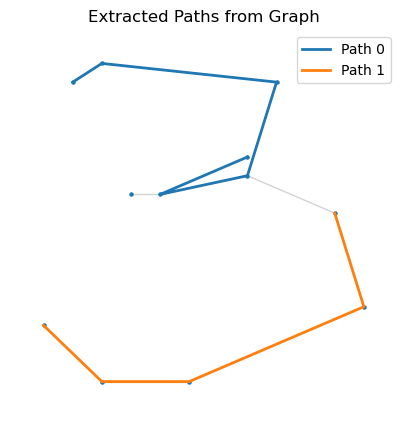

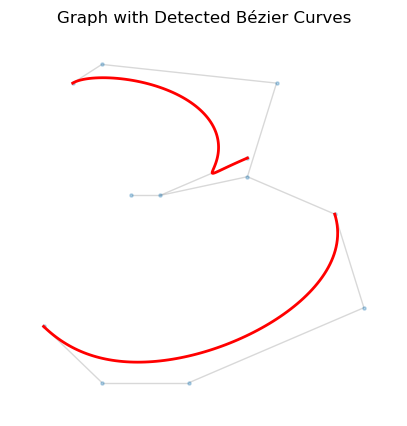

In [ ]:
import networkx as nx
import numpy as np
import bezier
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from scipy import ndimage as ndi

def extract_long_paths(G, min_length=3):
    visited = set()
    paths = []

    for node in G.nodes:
        if G.degree[node] == 1:  # endpoint
            path = [node]
            current = node
            prev = None
            while True:
                neighbors = list(G.neighbors(current))
                next_nodes = [n for n in neighbors if n != prev]
                if not next_nodes or next_nodes[0] in visited:
                    break
                prev = current
                current = next_nodes[0]
                path.append(current)
            if len(path) >= min_length:
                paths.append(path)
                visited.update(path)
    return paths

# Function to fit a Bézier curve to a given path
def fit_bezier_curve(path):
    # Extract x and y coordinates of the path
    x = np.array([node[0] for node in path])
    y = np.array([node[1] for node in path])
    
    # Create a Bézier curve using the coordinates (you can try fitting a higher degree)
    nodes = np.asfortranarray([x, y])
    curve = bezier.Curve(nodes, degree=len(nodes[0]) - 1)
    return curve

# Function to generate Bézier curve points for visualization
def get_bezier_curve_points(curve, num_points=100):
    # Generate points along the Bézier curve
    u_vals = np.linspace(0.0, 1.0, num_points)
    curve_points = curve.evaluate_multi(u_vals)
    return curve_points[0], curve_points[1]  # x and y

# Assuming merged_G is your graph, extract paths from it
paths = extract_long_paths(G1)

# Display extracted paths
fig, ax = plt.subplots(figsize=(5, 5))

# Draw the full graph in light gray
nx.draw(G1, pos={node: node for node in G1.nodes()}, 
        node_size=5, edge_color='lightgray', ax=ax)

# Overlay each path in a different color
for i, path in enumerate(paths):
    path_x = [node[0] for node in path]
    path_y = [node[1] for node in path]
    ax.plot(path_x, path_y, label=f'Path {i}', linewidth=2)

plt.title("Extracted Paths from Graph")
plt.legend()
plt.show()


# Number of nodes to sample from each path
num_sampled_nodes = 10

# Now fit Bézier curves to these paths and visualize
fig, ax = plt.subplots(figsize=(5, 5))

# Plot the original graph
# Draw the entire graph in light gray
pos = {node: node for node in G1.nodes()}  # Node positions
nx.draw(G1, pos, node_size=5, edge_color='gray', alpha=0.3, ax=ax)

# Loop through the paths and fit Bézier curves
for path in paths:
    # Sample a subset of nodes from the path (for example, 10 nodes)
    # sampled_path = sample_nodes_from_path(path, num_sampled_nodes)

    curve = fit_bezier_curve(path)  # Fit Bézier curve to the path
    bezier_x, bezier_y = get_bezier_curve_points(curve)  # Get the curve points

    # Plot the fitted Bézier curve
    plt.plot(bezier_x, bezier_y, label="Detected Curve", color="red", linewidth=2)

# Show the plot with Bézier curves
plt.title("Graph with Detected Bézier Curves")
plt.show()


## 05.2b Apply Bezier curves to all the digits

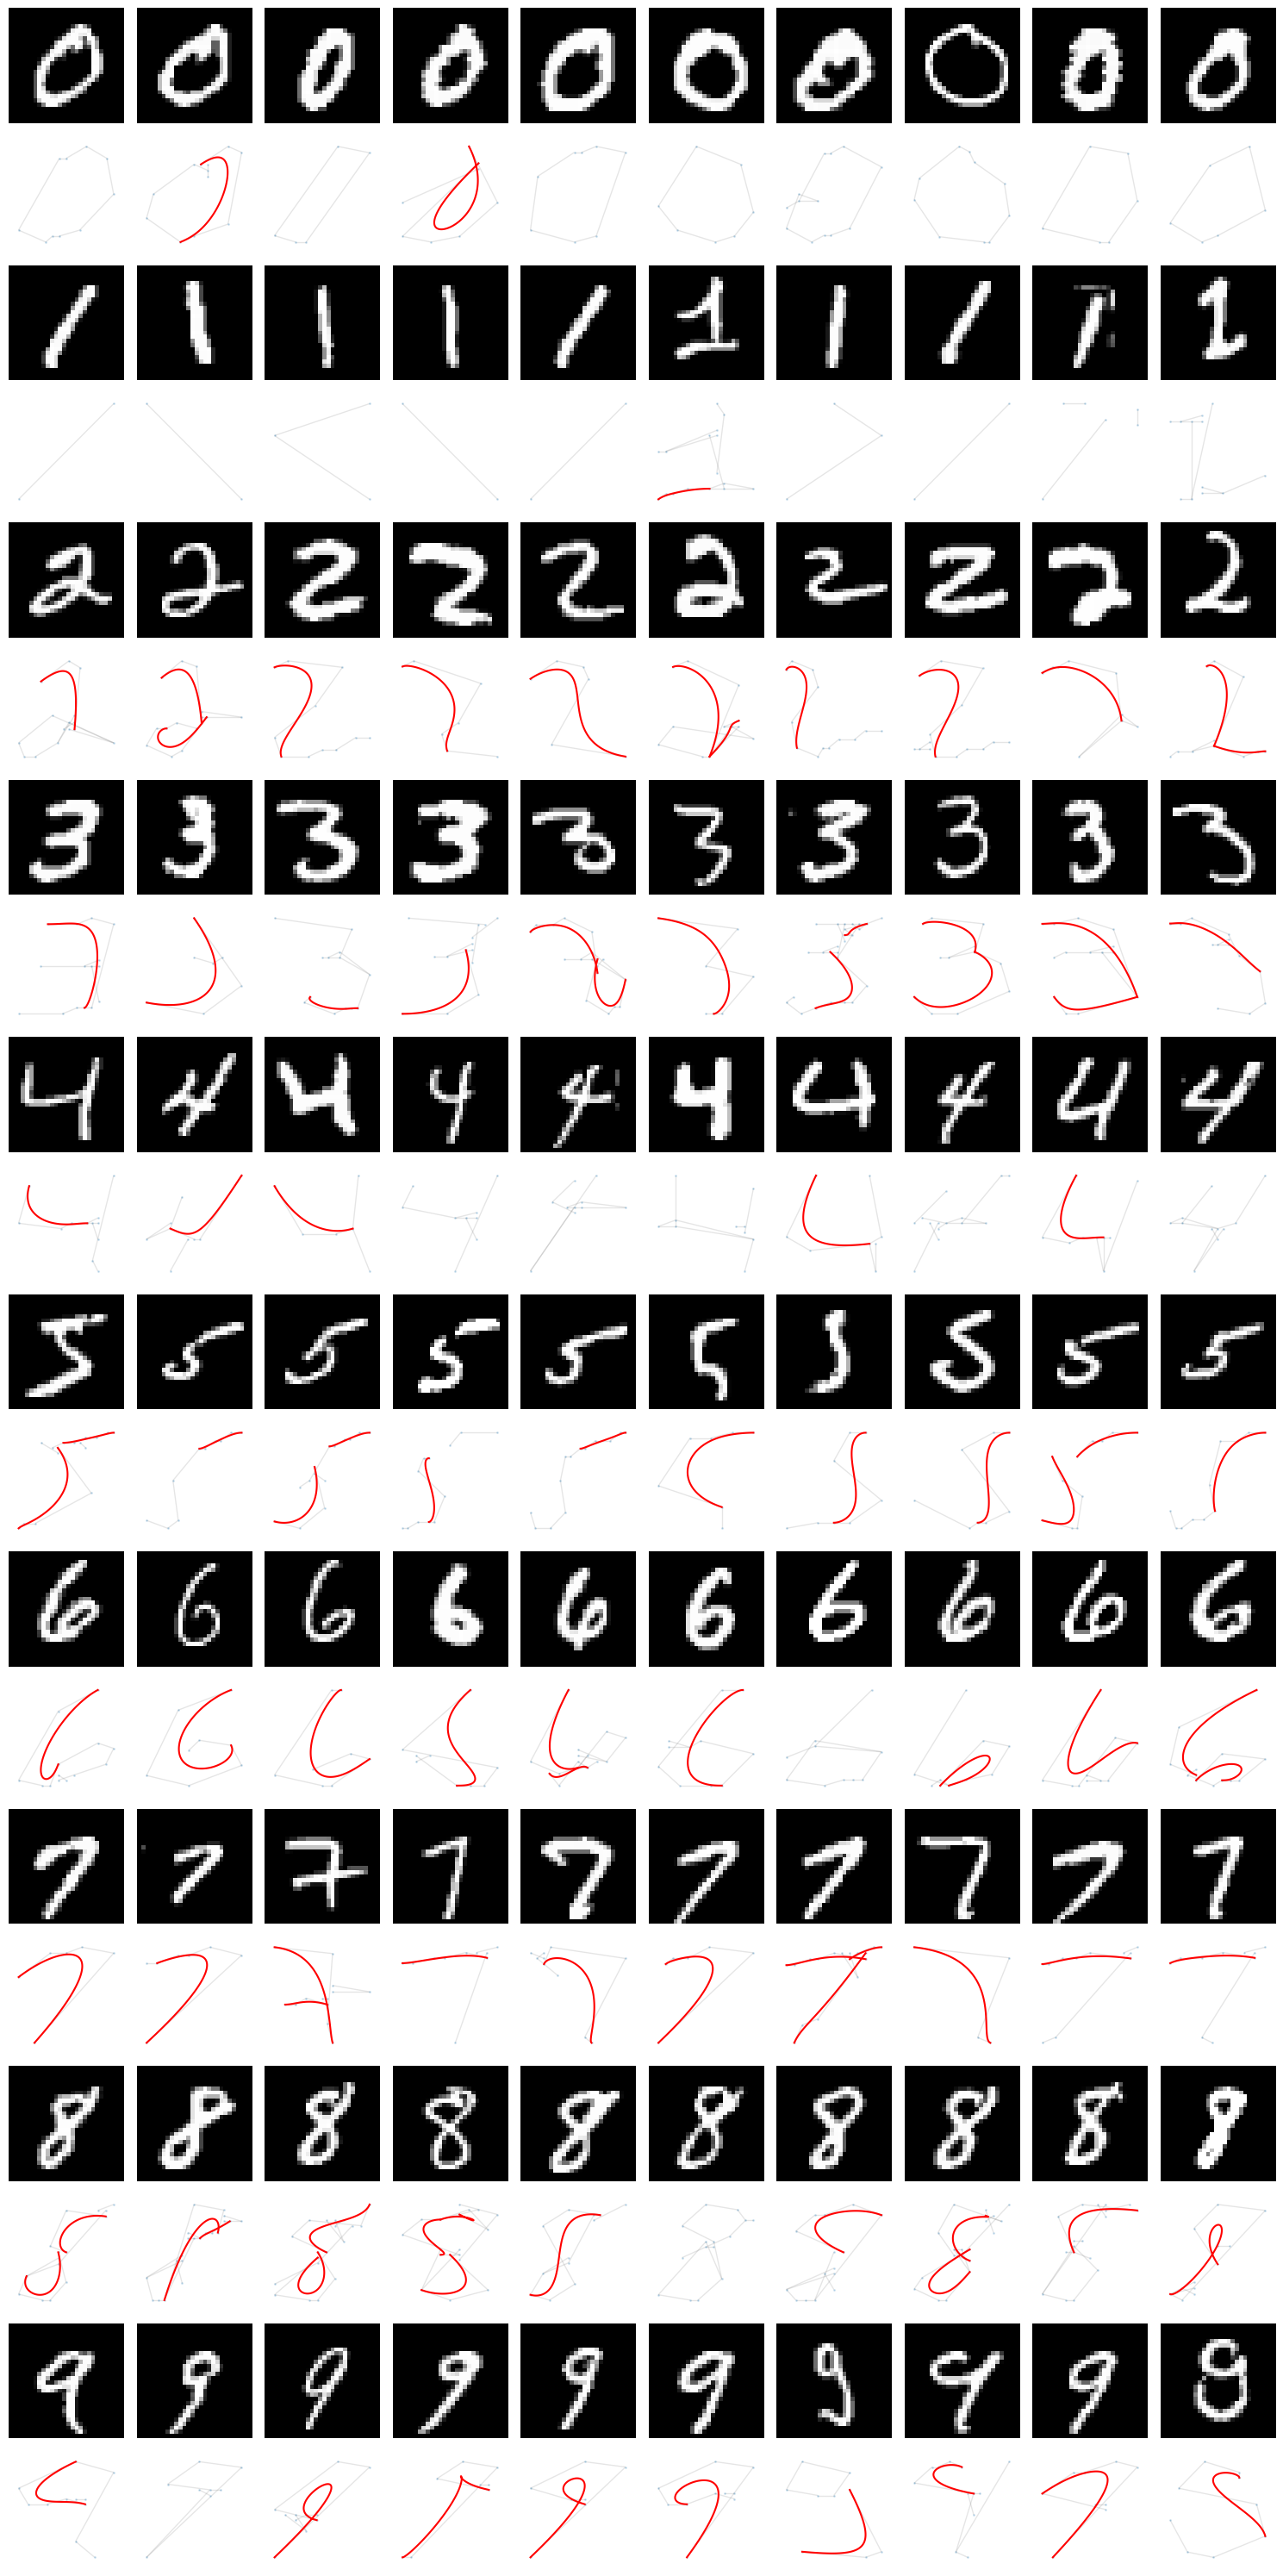

In [40]:
# --- Bézier utilities ---

def extract_paths_from_graph(G, min_length=4):
    paths = []
    visited = set()

    for node in G.nodes:
        if node in visited:
            continue
        neighbors = list(G.neighbors(node))
        if len(neighbors) == 1:
            path = [node]
            current = node
            prev = None
            while True:
                visited.add(current)
                next_nodes = [n for n in G.neighbors(current) if n != prev]
                if not next_nodes or len(next_nodes) > 1:
                    break
                prev = current
                current = next_nodes[0]
                path.append(current)
            if len(path) >= min_length:
                paths.append(path)
    return paths

def fit_bezier_curve(path):
    x = np.array([node[0] for node in path])
    y = np.array([node[1] for node in path])
    if len(x) < 2:
        return None  # Too few points
    degree = min(len(x) - 1, 5)  # Limit max degree to avoid instability
    nodes = np.asfortranarray([x, y])
    return bezier.Curve(nodes[:, :degree + 1], degree=degree)

def get_bezier_curve_points(curve, num_points=100):
    u_vals = np.linspace(0.0, 1.0, num_points)
    curve_points = curve.evaluate_multi(u_vals)
    return curve_points[0], curve_points[1]

def plot_graph_with_beziers(G, ax):
    pos = {node: node for node in G.nodes()}
    nx.draw(G, pos, node_size=1, edge_color='gray', alpha=0.2, ax=ax)

    paths = extract_paths_from_graph(G)
    for path in paths:
        curve = fit_bezier_curve(path)
        if curve:
            bx, by = get_bezier_curve_points(curve)
            ax.plot(bx, by, color="red", linewidth=1.5)

# --- Visualization of all digits with Bézier curves ---

fig, axes = plt.subplots(20, 10, figsize=(15, 30))

for i in range(10):
    images = x_train[y_train == i][:10]
    for j, image in enumerate(images):
        axes[2 * i, j].imshow(image, cmap='gray')
        axes[2 * i, j].axis('off')

        skeleton = preprocess_image(image)
        G = merge_similar_edges(extract_graph(skeleton), angle_threshold=50)

        plot_graph_with_beziers(G, axes[2 * i + 1, j])
        axes[2 * i + 1, j].axis('off')

plt.tight_layout()
plt.show()

## 06. Find cycles in the graphs

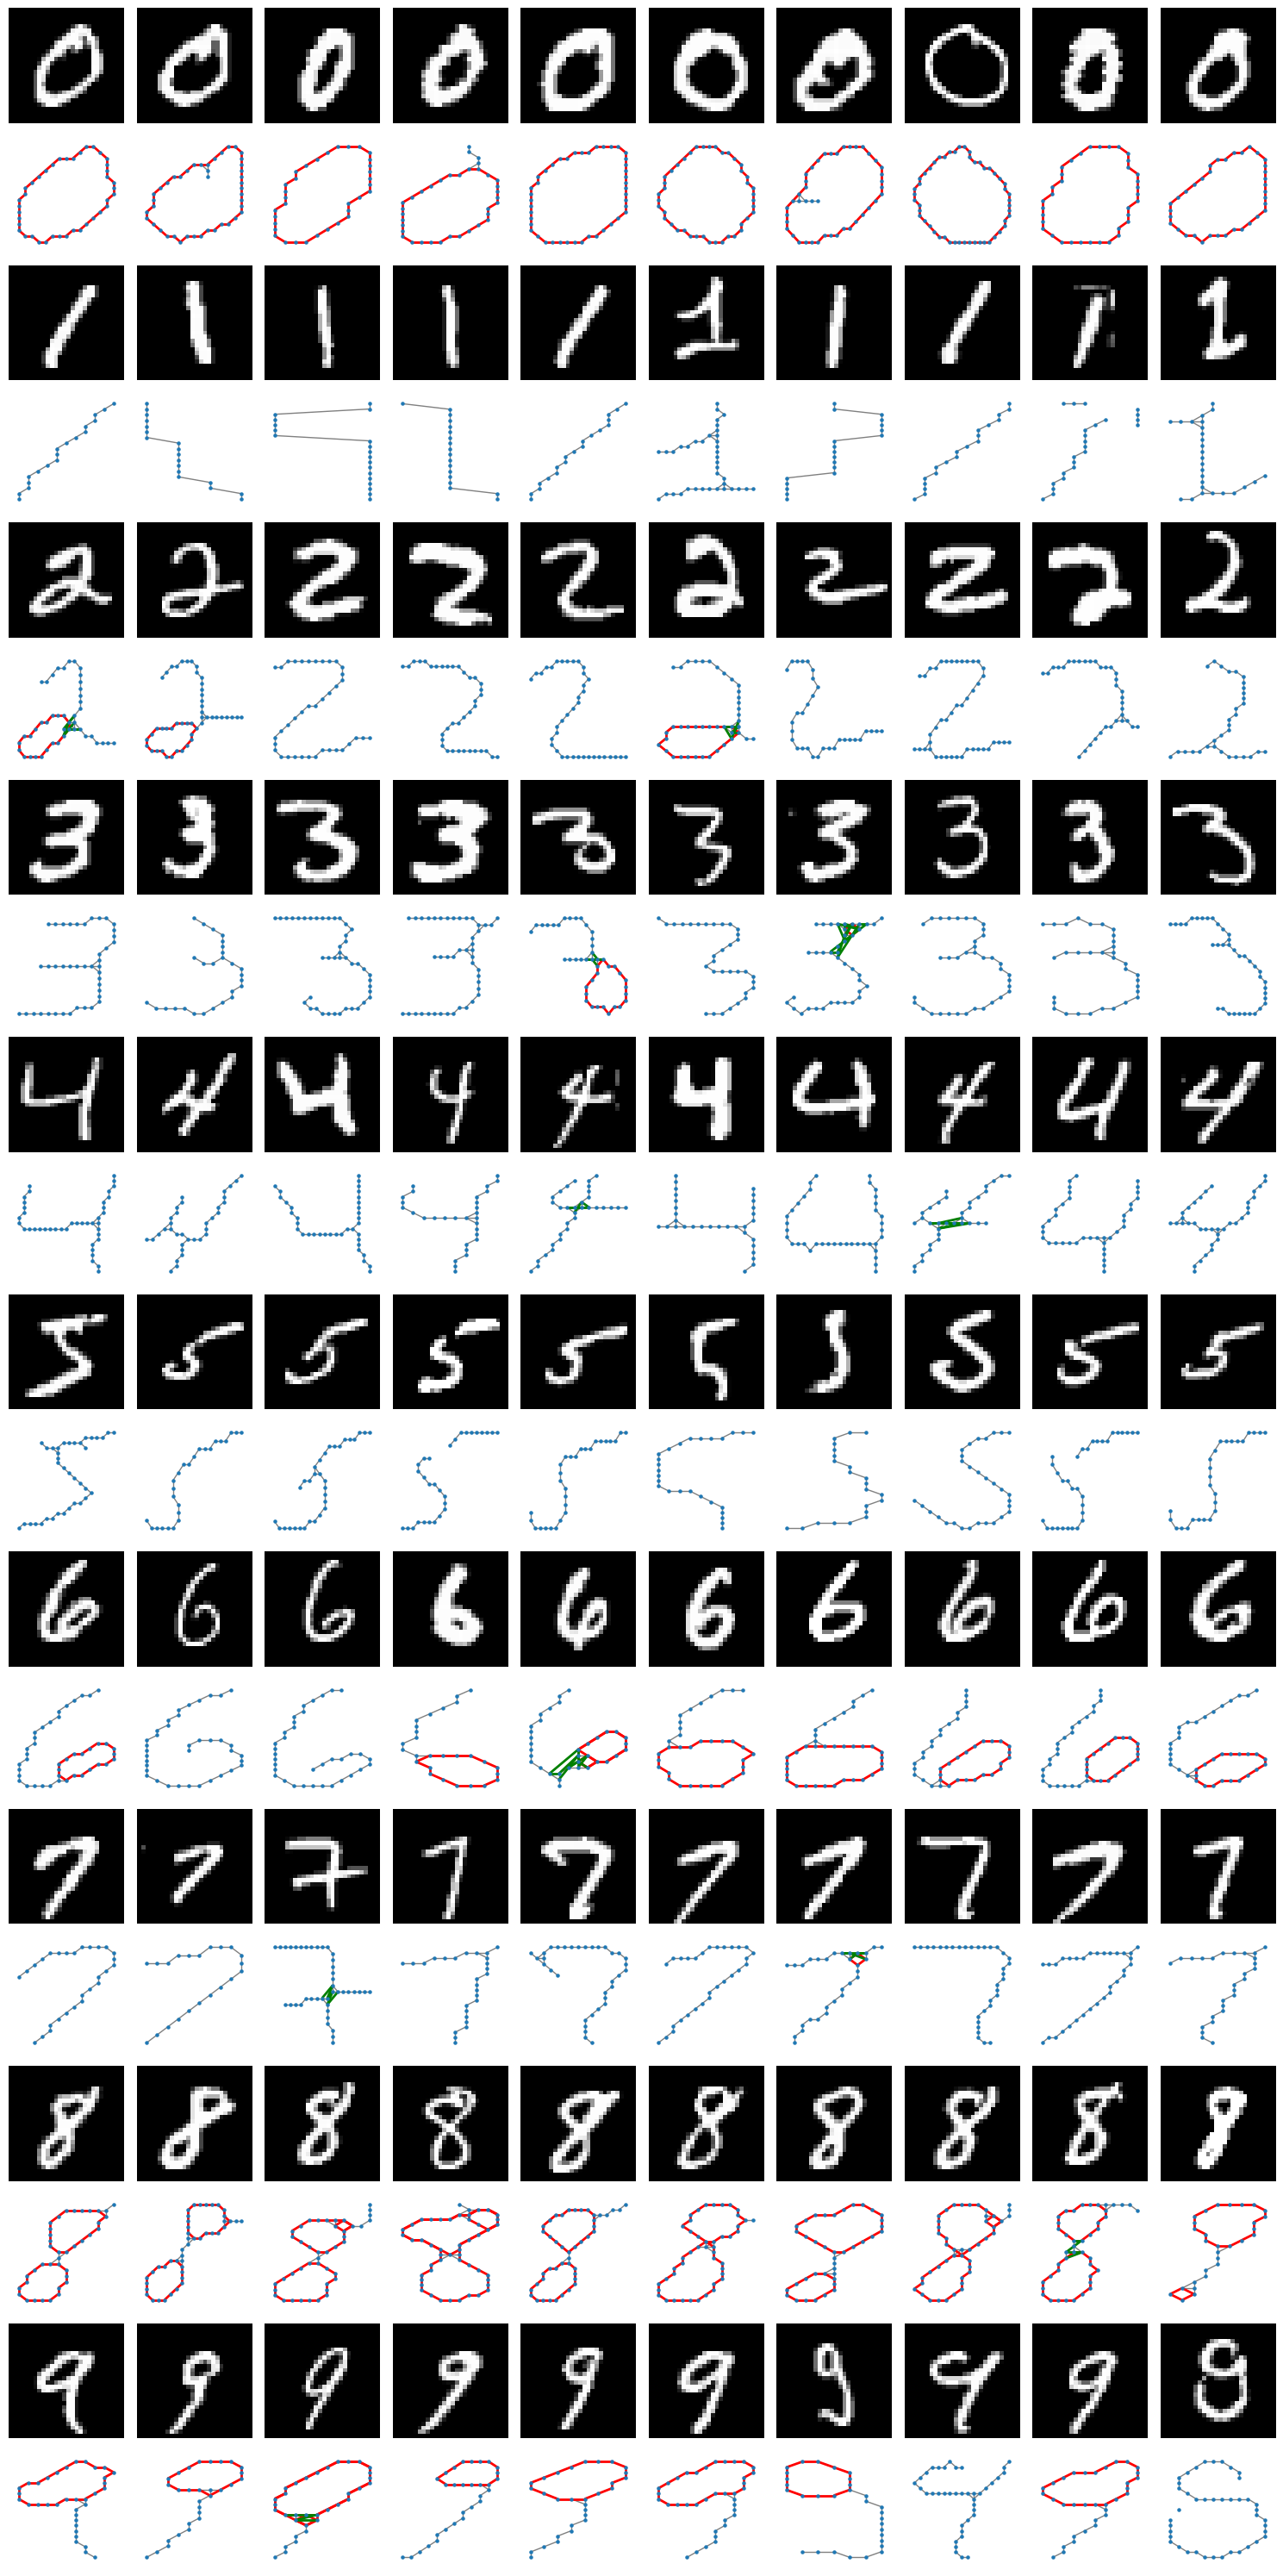

In [ ]:
def find_cycles(G):
    """Find all cycles in the graph using NetworkX's cycle basis method."""
    cycles = nx.cycle_basis(G)  # List of cycles (each cycle is a list of nodes)

    # filter out cycles with less than 4 nodes (not meaningful for digits)
    cycles = [cycle for cycle in cycles if len(cycle) > 3]
    return cycles

def plot_graph(G, ax, highlight_cycles=False, cycles=[], almost_cycles=[], ellipsoids=[]):
    """Plot the graph on the given axis with optional cycle highlighting."""
    pos = {node: node for node in G.nodes()}  # Use node positions as coordinates
    
    # Draw the full graph in gray
    nx.draw(G, pos, ax=ax, node_size=5, edge_color='gray', with_labels=False)
    
    if highlight_cycles:
        # Draw cycles with different colors
        for cycle in cycles:
            cycle_edges = [(cycle[i], cycle[i + 1]) for i in range(len(cycle) - 1)] + [(cycle[-1], cycle[0])]
            nx.draw_networkx_edges(G, pos, edgelist=cycle_edges, ax=ax, edge_color='red', width=2)
# Load the MNIST dataset
(x_train, y_train), _ = mnist.load_data()

# Create a figure with 20 rows (10 digits, each with image + graph) and 10 columns
fig, axes = plt.subplots(20, 10, figsize=(15, 30))

for i in range(10):  # Iterate through digits 0-9
    images = x_train[y_train == i][:10]  # Get first 5 images of digit i
    for j, image in enumerate(images):
        axes[2 * i, j].imshow(image, cmap='gray')
        axes[2 * i, j].axis('off')
        
        skeleton = preprocess_image(image)
        G = extract_graph(skeleton)
        cycles = find_cycles(G)  # Detect cycles in the graph
        
        # Plot original graph
        plot_graph(G, axes[2 * i + 1, j], highlight_cycles=True, cycles=cycles, almost_cycles=almost_cycles, ellipsoids=ellsoids)
        axes[2 * i + 1, j].axis('off')

plt.tight_layout()
plt.show()


## 07. Delete cycles from the graphs

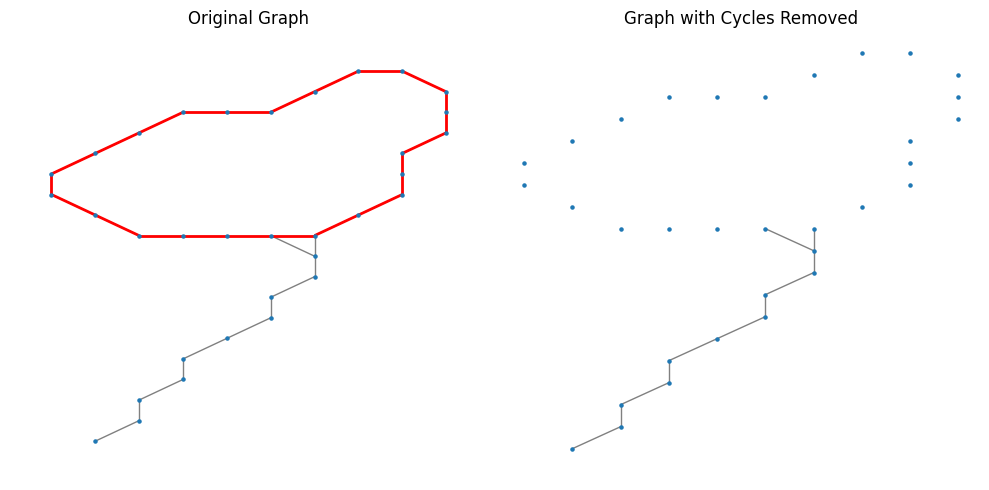

In [ ]:
# Delete cycles from the graphs
def remove_cycles(G, cycles):
    """Remove the given cycles from the graph."""
    G_copy = G.copy()
    for cycle in cycles:
        for i in range(len(cycle) - 1):
            G_copy.remove_edge(cycle[i], cycle[i + 1])
        G_copy.remove_edge(cycle[-1], cycle[0])  # Close the cycle
    return G_copy


# Test cycle removal on a sample digit
image = x_train[y_train == 9][8]  # Get the first image of digit '3'
skeleton = preprocess_image(image)
G = extract_graph(skeleton)
cycles = find_cycles(G)  # Detect cycles in the graph
G_no_cycles = remove_cycles(G, cycles)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_graph(G, axes[0], highlight_cycles=True, cycles=cycles)
axes[0].set_title("Original Graph")
plot_graph(G_no_cycles, axes[1])
axes[1].set_title("Graph with Cycles Removed")

plt.tight_layout()
plt.show()

In [ ]:
# remove not connected nodes
def remove_not_connected_nodes(G):
    """Remove nodes that are not part of any edge."""
    isolated_nodes = list(nx.isolates(G))
    G_copy = G.copy()
    G_copy.remove_nodes_from(isolated_nodes)
    return G_copy

G_no_cycles_clean = remove_not_connected_nodes(G_no_cycles)

print("info about the graph without cycles and isolated nodes")
print("Nodes:", G_no_cycles_clean.number_of_nodes())
print("Edges:", G_no_cycles_clean.number_of_edges())

G_merged = merge_similar_edges(G_no_cycles, angle_threshold=50)

# Plot the merged graph with cycles
fig, ax = plt.subplots(figsize=(5, 5))
plot_graph(G_merged, ax, highlight_cycles=True)
plt.title("Merged Graph with Cycles")
plt.show()

info about the graph without cycles and isolated nodes
Nodes: 12
Edges: 11


KeyError: (15, -15)